In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configurando o estilo das visualizações
plt.style.use('ggplot')
sns.set(style='whitegrid')

In [3]:
# 1. Carregando os dados
df = pd.read_csv('breast_cancer.csv')

# 2. Analisando os dados
print("Informações do dataset:")
print(df.info())
print("\nEstatísticas descritivas:")
print(df.describe())

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             175 non-null    int64  
 1   BMI             175 non-null    float64
 2   Glucose         175 non-null    int64  
 3   Insulin         175 non-null    float64
 4   HOMA            175 non-null    float64
 5   Leptin          175 non-null    float64
 6   Adiponectin     175 non-null    float64
 7   Resistin        175 non-null    float64
 8   MCP.1           175 non-null    float64
 9   Classification  175 non-null    int64  
dtypes: float64(7), int64(3)
memory usage: 13.8 KB
None

Estatísticas descritivas:
             Age         BMI     Glucose     Insulin        HOMA      Leptin  \
count  175.00000  175.000000  175.000000  175.000000  175.000000  175.000000   
mean    57.48000   27.530602  100.828571   10.896189    3.038455   27.011812   
std     

In [4]:
# Verificando a distribuição das classes
print("\nDistribuição das classes:")
print(df['Classification'].value_counts())


Distribuição das classes:
Classification
2    123
1     52
Name: count, dtype: int64


In [5]:
# 3. Verificando dados ausentes
print("\nVerificando dados ausentes:")
print(df.isnull().sum())


Verificando dados ausentes:
Age               0
BMI               0
Glucose           0
Insulin           0
HOMA              0
Leptin            0
Adiponectin       0
Resistin          0
MCP.1             0
Classification    0
dtype: int64


In [6]:
# 4. Verificando dados duplicados
print("\nNúmero de entradas duplicadas:", df.duplicated().sum())


Número de entradas duplicadas: 59


In [7]:
# Removendo as entradas duplicadas
df_clean = df.drop_duplicates()
print("Número de entradas após remoção de duplicatas:", len(df_clean))
print("Distribuição das classes após remoção de duplicatas:")
print(df_clean['Classification'].value_counts())

Número de entradas após remoção de duplicatas: 116
Distribuição das classes após remoção de duplicatas:
Classification
2    64
1    52
Name: count, dtype: int64


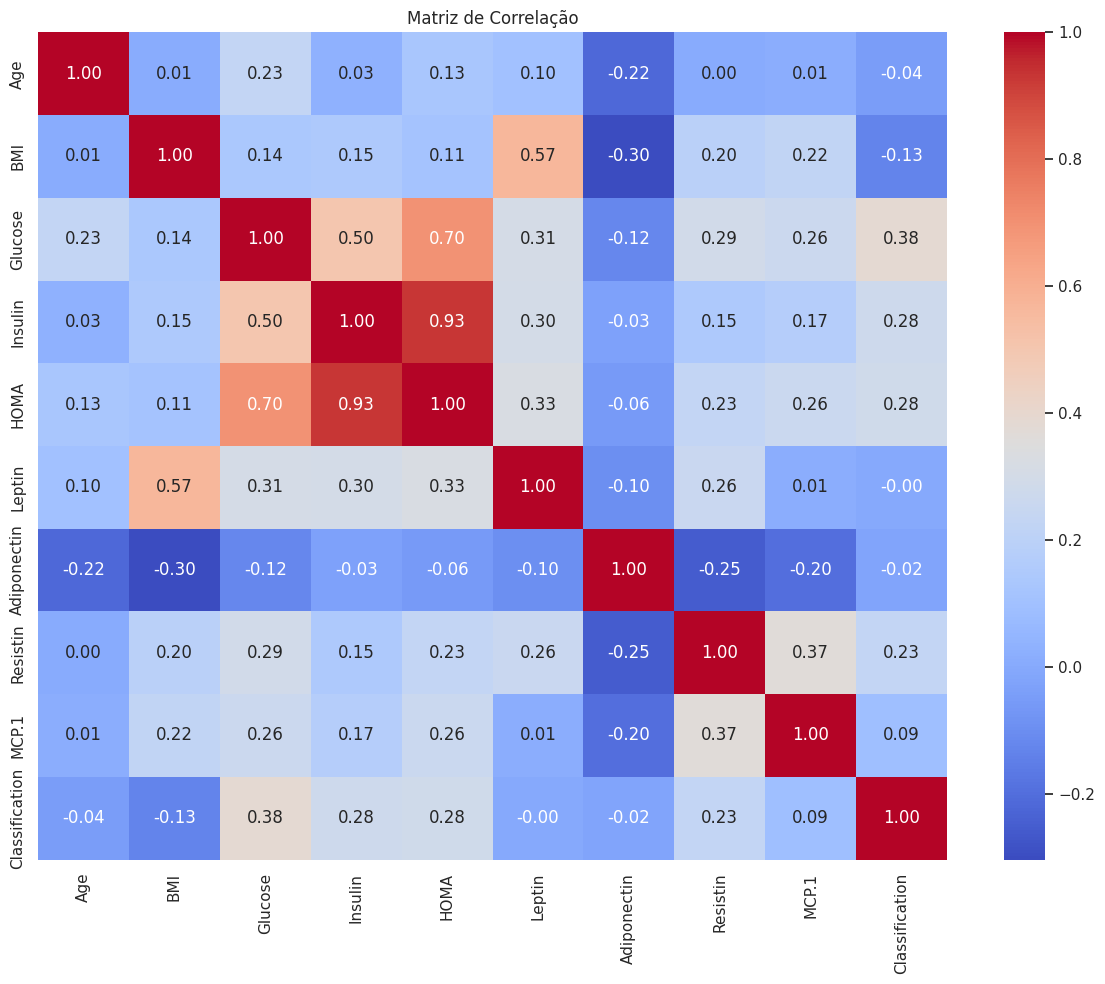

In [19]:
# 5. Análise exploratória dos dados
# Criando uma matriz de correlação
plt.figure(figsize=(12, 10))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
#plt.close()

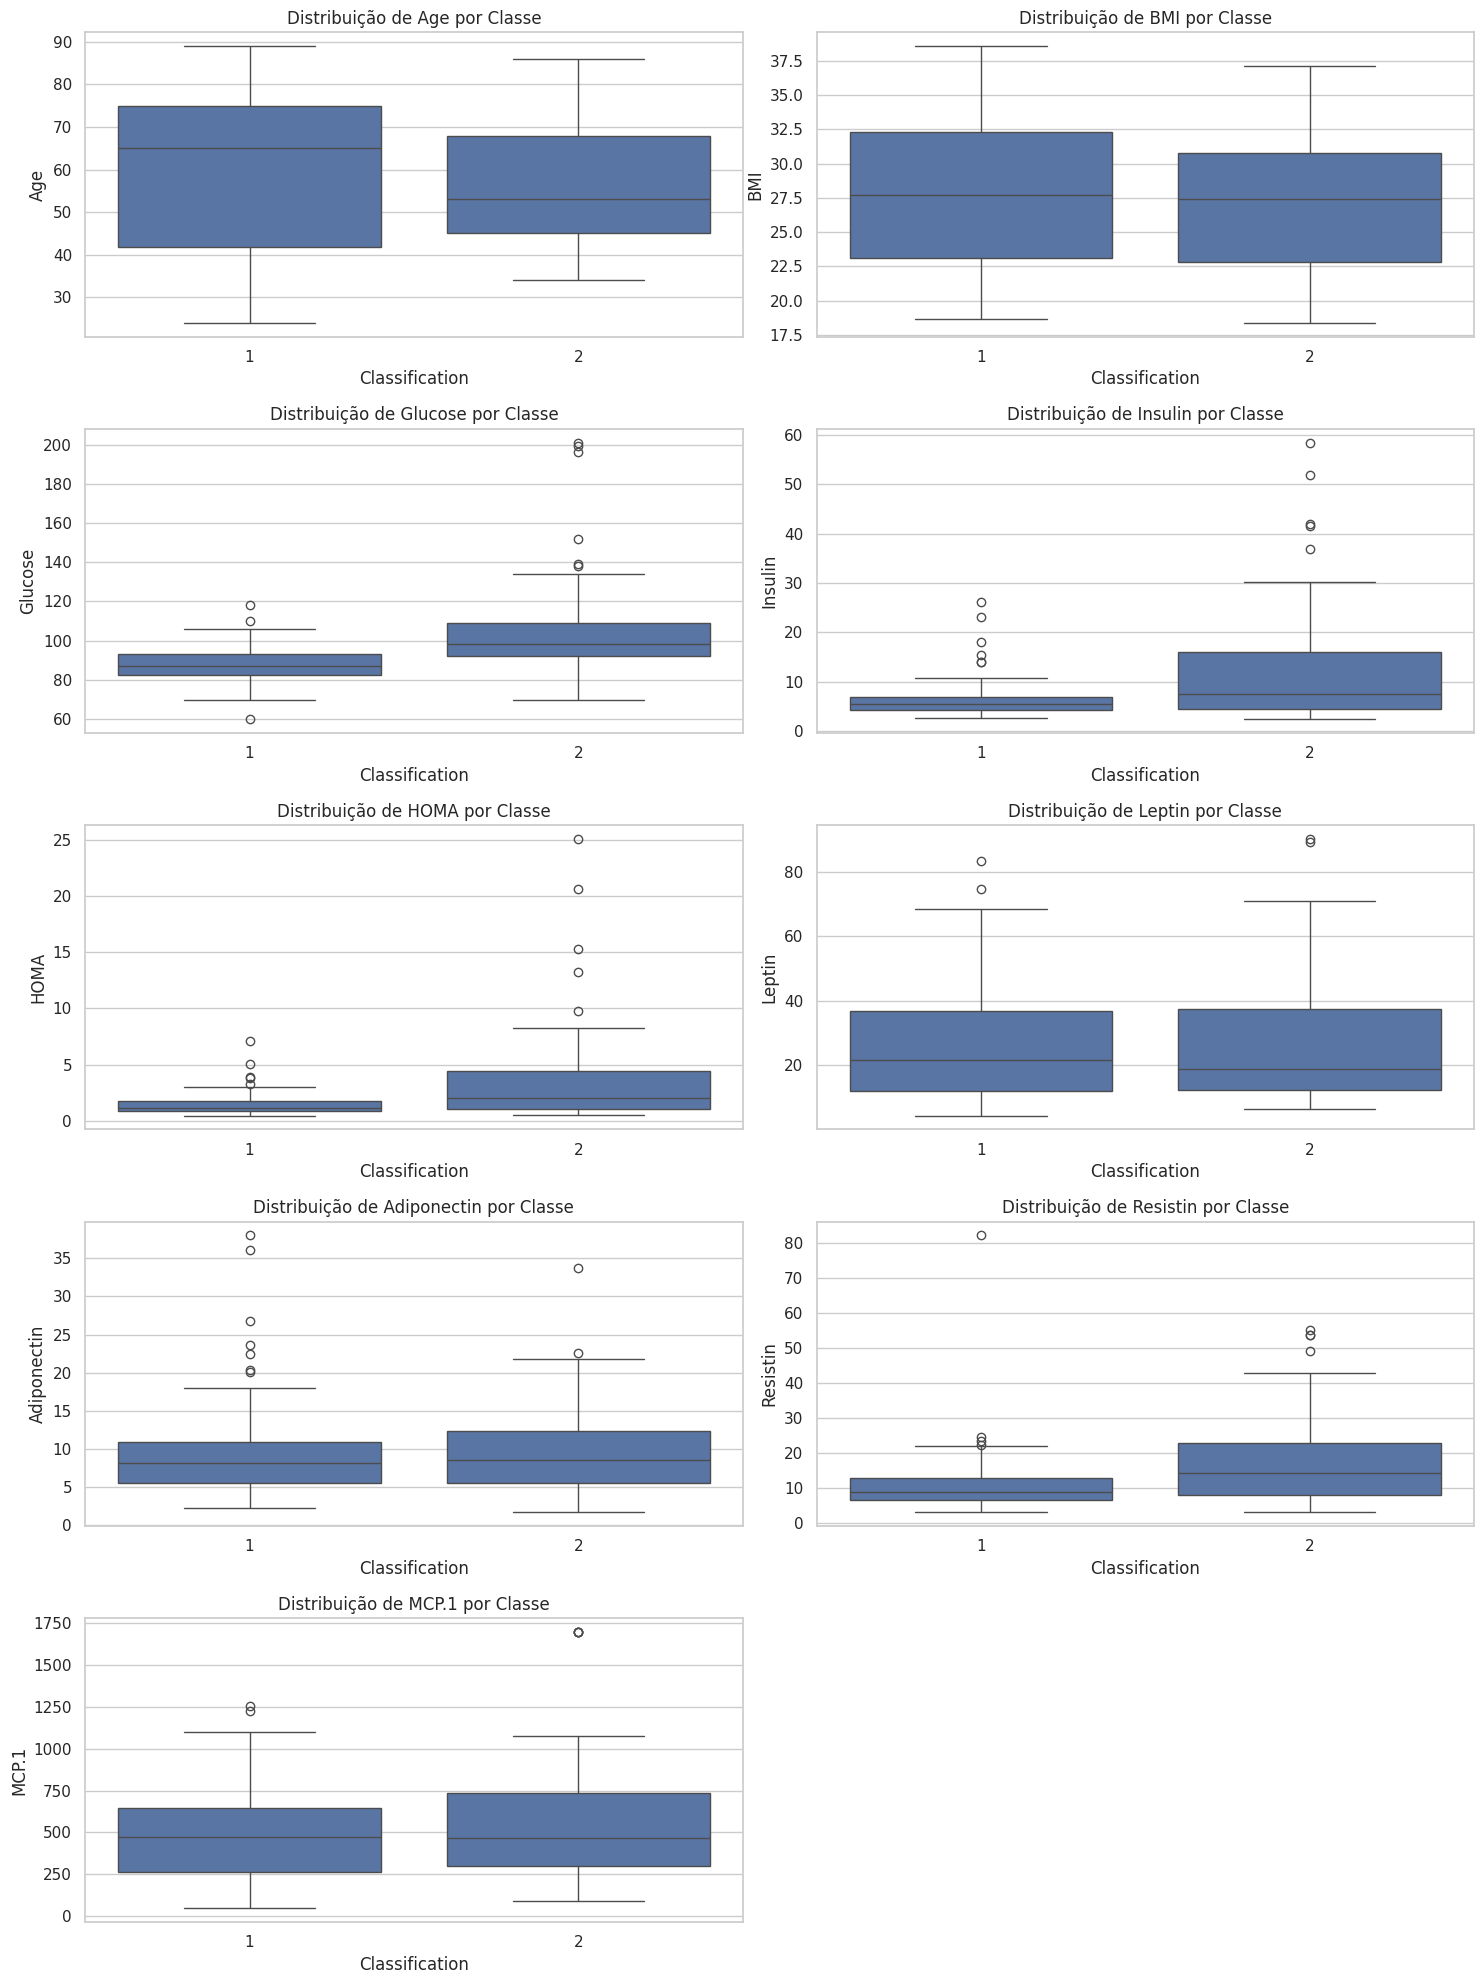

In [20]:
# Comparando as distribuições das variáveis entre as classes
features = ['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP.1']

plt.figure(figsize=(15, 20))
for i, feature in enumerate(features):
    plt.subplot(5, 2, i+1)
    sns.boxplot(x='Classification', y=feature, data=df_clean)
    plt.title(f'Distribuição de {feature} por Classe')
plt.tight_layout()
plt.savefig('feature_distributions.png')
#plt.close()

In [11]:
# 6. Preparando os dados para o treinamento
X = df_clean.drop('Classification', axis=1)
y = df_clean['Classification']

In [12]:
# 7. Balanceamento dos dados
# Aplicando RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)

In [13]:
# Aplicando TomekLinks
tl = TomekLinks(sampling_strategy='all')
X_resampled, y_resampled = tl.fit_resample(X_rus, y_rus)

print("\nDistribuição das classes após balanceamento:")
print(pd.Series(y_resampled).value_counts())


Distribuição das classes após balanceamento:
Classification
1    45
2    45
Name: count, dtype: int64


In [14]:
# 8. Dividindo os dados em conjuntos de treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

In [15]:
# 9. Treinando o modelo Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=100)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=100, random_state=42)

In [16]:
# 10. Fazendo previsões
y_pred = rf_model.predict(X_test)


Matrix de Confusão:
[[12  3]
 [ 3  9]]

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.80      0.80      0.80        15
           2       0.75      0.75      0.75        12

    accuracy                           0.78        27
   macro avg       0.78      0.78      0.78        27
weighted avg       0.78      0.78      0.78        27


Acurácia do modelo: 0.7777777777777778


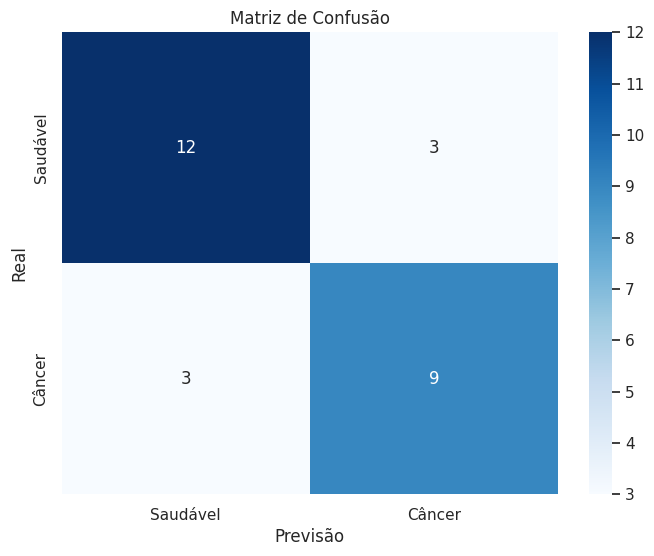

In [22]:
# 11. Avaliando o modelo
print("\nMatrix de Confusão:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=['Saudável', 'Câncer'],
            yticklabels=['Saudável', 'Câncer'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.savefig('confusion_matrix.png')
#plt.close()

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

print("\nAcurácia do modelo:", accuracy_score(y_test, y_pred))

In [18]:
# 12. Analisando a importância das características
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nImportância das características:")
print(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Importância das Características')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.close()


Importância das características:
       Feature  Importance
7     Resistin    0.273508
2      Glucose    0.172462
0          Age    0.111805
1          BMI    0.101245
4         HOMA    0.089475
3      Insulin    0.082542
5       Leptin    0.062037
8        MCP.1    0.053907
6  Adiponectin    0.053019


In [23]:
# Filtrando apenas os casos diagnosticados com câncer
cancer_cases = df_clean[df_clean['Classification'] == 1]

# Calculando a média de glicose para esses casos
mean_glucose = cancer_cases['Glucose'].mean()

print(f"Média de glicose entre os diagnosticados com câncer: {mean_glucose:.2f}")

Média de glicose entre os diagnosticados com câncer: 88.23


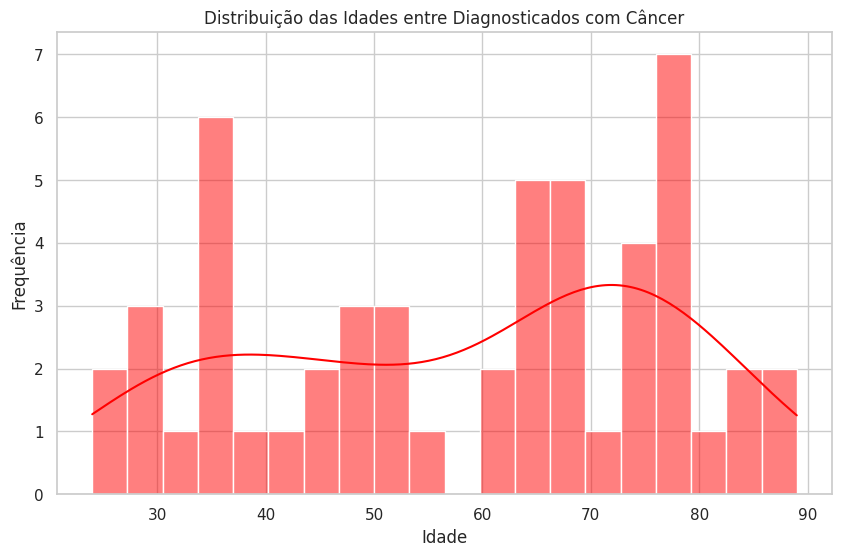

In [24]:
# Filtrando os casos diagnosticados com câncer
cancer_cases = df_clean[df_clean['Classification'] == 1]

# Criando o histograma
plt.figure(figsize=(10, 6))
sns.histplot(cancer_cases['Age'], bins=20, kde=True, color='red')

# Configurações do gráfico
plt.title('Distribuição das Idades entre Diagnosticados com Câncer')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.grid(True)

# Salvando e exibindo o gráfico
plt.savefig('histograma_idades_cancer.png')
plt.show()

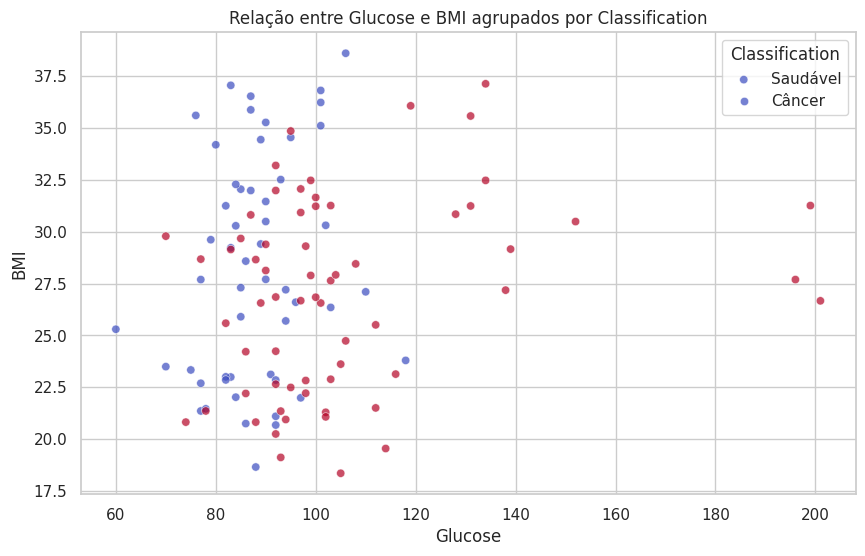

In [25]:
# Criando o gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Glucose', y='BMI', hue='Classification', palette='coolwarm', alpha=0.7)

# Configurações do gráfico
plt.title('Relação entre Glucose e BMI agrupados por Classification')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.legend(title='Classification', labels=['Saudável', 'Câncer'])
plt.grid(True)

# Salvando e exibindo o gráfico
plt.savefig('scatter_glucose_bmi.png')
plt.show()

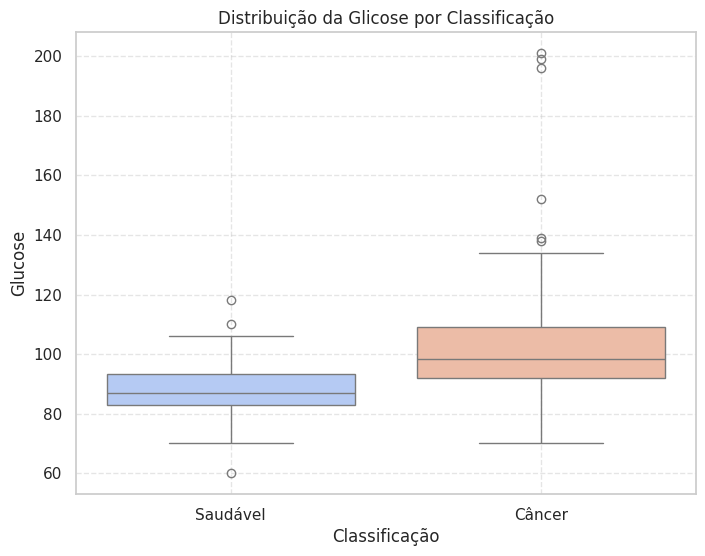

In [26]:
# Criando o boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='Classification', y='Glucose', palette='coolwarm')

# Configurações do gráfico
plt.title('Distribuição da Glicose por Classificação')
plt.xlabel('Classificação')
plt.ylabel('Glucose')
plt.xticks(ticks=[0, 1], labels=['Saudável', 'Câncer'])
plt.grid(True, linestyle='--', alpha=0.5)

# Salvando e exibindo o gráfico
plt.savefig('boxplot_glucose_classification.png')
plt.show()